In [1]:
import os.path, pickle, subprocess, scipy
import numpy as np
import Functional_Fusion.atlas_map as am
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath
import DCBC.dcbc as DCBC
from scipy.stats import ttest_ind

In [2]:
projectPath, mainResultsPath = setProjectPath()

dataset_name = 'MDTB' # or Demand

surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')

resultsPath = os.path.join(mainResultsPath, 'START_A4_DCBC', dataset_name)
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

# load cortical parcellation from label.gii file
glasser_L = os.path.join(surface_helpers_dir, 'glasser.L.label.gii')
glasser_R = os.path.join(surface_helpers_dir, 'glasser.R.label.gii')

# extract the first data array as the parcels
# make sure that the input parcels are of shape (N,)
gii_file = nib.load(glasser_L)
# gii_file = nib.load(glasser_R)
parcels_inds = gii_file.darrays[0].data

# label table: which can be exported using wb_command -label-export-table glasser_L
TXT_label_L = os.path.join(surface_helpers_dir, 'glasser.L.label.txt')
TXT_label_R = os.path.join(surface_helpers_dir, 'glasser.R.label.txt')

label_table = pd.read_csv(TXT_label_L, header=None)
all_parcels = [label_table.loc[k, :].to_string().split()[1].replace('_ROI', '').replace('L_', '') for k in np.arange(len(label_table)) if np.mod(k, 2) == 0]
all_indices = [int(label_table.loc[k, :].to_string().split()[1]) for k in np.arange(len(label_table)) if np.mod(k, 2) == 1]
dict_parcel_indices = {all_parcels[i]: all_indices[i] for i in np.arange(len(all_parcels))}

# Get the atlas
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

In [3]:
# defining ROIs
large_ROI = 'PFC'
parcels_ROI = ['OFC', '10pp', '10r', '8C', 's6-8', '25', 'p24', 'p47r', '46', 'a10p', '10d', '9m', '8Av', 'IFJp', '10v', '13l', '45', 'i6-8', '9-46d', 'IFJa', '47s', 'SFL', 'a24', 'IFSp', '47m', '9p', '9a', 'pOFC', '8Ad', '11l', 'IFSa', 'a9-46v', '44', 'a47r', '55b', '47l', 's32', 'p9-46v', '8BM', 'p10p', '8BL', 'p32', 'a32pr', 'd32']    # PNAS paper

# large_ROI = 'visual'
# parcels_ROI = ['V1', 'V2', 'V3', 'V4']

# large_ROI = 'somatosensory'
# parcels_ROI = ['4', '3a', '3b', '1', '2']

# large_ROI = 'parietal'
# parcels_ROI = ['7AL', '7Am', '7Pm', '7PL', 'MIP', 'VIP', '7PC', 'LIPv', 'AIP', 'LIPd']

indices_ROI = [dict_parcel_indices[k] for k in parcels_ROI]

output = dict()
PKL_output = os.path.join(resultsPath, f'{dataset_name}_{large_ROI}_output.pkl')


In [4]:
# get all the vertices that are in the ROI list
vertex_label_ROI, vertex_ind_ROI = [], []
for i, label in enumerate(parcels_inds):
    if label in indices_ROI:
        vertex_label_ROI.append(label)
        vertex_ind_ROI.append(i)

vertex_label_ROI = np.array(vertex_label_ROI)
vertex_ind_ROI = np.array(vertex_ind_ROI)

In [5]:
MAT_dist = os.path.join(projectPath, 'code', 'DCBC', 'distanceMatrix', 'distAvrg_sp.mat')
spatialMat = scipy.io.loadmat(MAT_dist)['avrgDs']

spatialMat = spatialMat[vertex_ind_ROI, :]
spatialMat = spatialMat[:, vertex_ind_ROI]

In [6]:
gii_files = []
for hemi in ['L', 'R']:
    if hemi == 'L':
        glasser_label = glasser_L
        flat_shape = os.path.join(surface_helpers_dir, 'fs_LR.32k.L.flat.surf.gii')
    else:
        glasser_label = glasser_R
        flat_shape = os.path.join(surface_helpers_dir, 'fs_LR.32k.R.flat.surf.gii')

    meta = nib.load(flat_shape).meta
    out_gii_file = os.path.join(resultsPath, f'roi_{hemi}.func.gii')
    roi_data = []
    for roi in parcels_ROI:
        hemi_roi = f'{hemi}_{roi}'
        out_label = os.path.join(resultsPath, f'{hemi_roi}.func.gii')
        wb_cmd = f'wb_command -gifti-label-to-roi {glasser_label} {out_label} -name {hemi_roi}_ROI'
        subprocess.run(wb_cmd, shell=True)
        roi_data.append(nib.load(out_label).agg_data())
    roi_data = np.array(roi_data).sum(axis=0)
    out_data = nib.gifti.gifti.GiftiImage(meta=meta)
    out_data.add_gifti_data_array(nib.gifti.gifti.GiftiDataArray(data=roi_data))
    nib.save(out_data, out_gii_file)
    gii_files.append(out_gii_file)

# roi L, R hemispheres
label_vec, labels = atlas.get_parcel(gii_files)

# only keep vertices that are within selected ROIs
included_vtx_inds_LR = np.where(label_vec > 0)[0]
included_vtx_inds_L = np.where(label_vec == 1)[0]
included_vtx_inds_R = np.where(label_vec == 2)[0]
excluded_vtx_inds_LR = np.where(label_vec == 0)[0]

In [7]:
# loading MDTB dataset
PKL_data = os.path.join(projectPath, 'data', f'{dataset_name}_Cond_All.pkl')
with open(PKL_data, 'rb') as pf:
    original_data = pickle.load(pf)
    X_individuals = original_data['X_individuals']
    info_individuals = original_data['info_individuals']
    dataset_obj_individuals = original_data['dataset_obj_individuals']

cond_vec = list(info_individuals[dataset_obj_individuals.cond_ind])

# whole cortex
data = X_individuals[:, :, included_vtx_inds_L]

# fill nans with 0
data[np.isnan(data)] = 0

n_subjects, n_conditions, n_vertices = data.shape

In [8]:
results = []
within_corrs = []
between_corrs = []

for subjI in np.arange(n_subjects):
    myDCBC = DCBC.compute_DCBC(maxDist=35, binWidth=5, parcellation=vertex_label_ROI, func=data[subjI].T, dist=spatialMat, backend='numpy')
    results.append(myDCBC)
    within_corrs.append(myDCBC['corr_within'])
    between_corrs.append(myDCBC['corr_between'])


In [9]:
within_corrs = np.array(within_corrs)
between_corrs = np.array(between_corrs)
within_corrs_mean = np.mean(within_corrs, axis=0)
within_corrs_ste = np.std(within_corrs, axis=0) / np.sqrt(n_subjects)
between_corrs_mean = np.mean(between_corrs, axis=0)
between_corrs_ste = np.std(between_corrs, axis=0) / np.sqrt(n_subjects)

In [10]:
## testing weather within-between is significantly higher than 0
dcbc_vals = within_corrs - between_corrs
ttest_result = ttest_ind(dcbc_vals, 0, axis=0, alternative='greater')
significance_level = 0.05
significant_distances = ttest_result.pvalue < significance_level

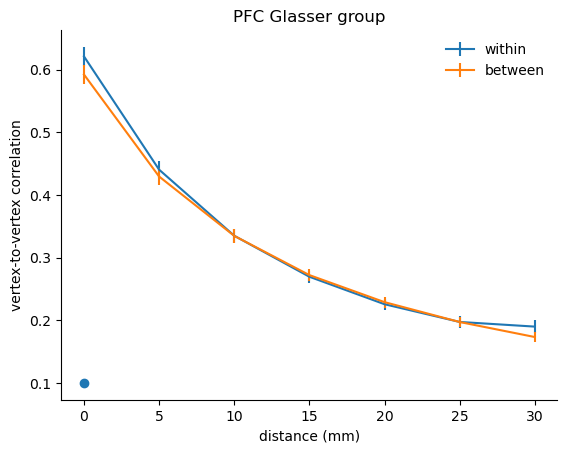

In [11]:
fig, ax = plt.subplots(1, 1)
ax.errorbar(np.arange(0, 35, step=5), within_corrs_mean, yerr = within_corrs_ste)
ax.errorbar(np.arange(0, 35, step=5), between_corrs_mean, yerr=between_corrs_ste)
ax.set_xlabel('distance (mm)')
ax.set_ylabel('vertex-to-vertex correlation')
ax.set_yticks(np.arange(0.1, 0.61, step=0.1))
ax.set_title(f'{large_ROI} Glasser group')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(['within', 'between'], frameon=False)
if any(significant_distances):
    ax.scatter(np.arange(0, 35, step=5)[significant_distances], 0.1*np.ones(np.sum(significant_distances)))

In [12]:
output['dcbc_results'] = results
output['within_corrs'] = within_corrs
output['between_corrs'] = between_corrs

with open(PKL_output, 'wb') as pk:
    pickle.dump(output, pk)